# Pattern Restoration Cluster Inspector

**Candidate cluster**: 9 tasks where a masked region (uniform-colour block) must be restored
by inferring the underlying pattern via reflection or translation.

- **Reflection-based** (4 tasks): masked hole in a symmetric pattern — fill by mirroring
- **Translation/periodic-based** (5 tasks): masked hole in a repeating pattern — fill by tiling

Grids load from local `data/training/` if accessible, else `/tmp/arc-data/data/training` (ARC-AGI clone).

In [1]:
%matplotlib inline
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

ARC_COLORS = ['#000000','#0074D9','#FF4136','#2ECC40','#FFDC00',
               '#AAAAAA','#F012BE','#FF851B','#7FDBFF','#870C25']
CMAP = mcolors.ListedColormap(ARC_COLORS)
NORM = mcolors.BoundaryNorm(range(11), CMAP.N)

def _find_data_dir():
    '''Walk up from cwd; test that a probe file is actually readable.'''
    probe = '4c4377d9.json'
    candidates = []
    p = Path.cwd()
    for _ in range(8):
        td = p / 'data' / 'training'
        if td.exists():
            candidates.append(td)
        p = p.parent
    candidates.append(Path('/tmp/arc-data/data/training'))  # fallback
    for td in candidates:
        try:
            (td / probe).read_text()  # will raise if inaccessible
            print(f'Using data dir: {td}')
            return td
        except Exception:
            continue
    raise FileNotFoundError(
        'Could not find readable ARC training data. '
        'Run: git clone --depth=1 https://github.com/fchollet/ARC-AGI.git /tmp/arc-data'
    )

DATA_DIR = _find_data_dir()

def show_grid(ax, grid, title, highlight=False):
    ax.imshow(np.array(grid), cmap=CMAP, norm=NORM, interpolation='nearest')
    ax.set_title(title, fontsize=8)
    ax.axis('off')
    if highlight:
        for spine in ax.spines.values():
            spine.set_edgecolor('#8B0000')
            spine.set_linewidth(2)

Using data dir: /Users/rodhyde/Documents/GitHub/arc-agi-solver/data/training


In [ ]:
# Pattern restoration candidate cluster (9 tasks)
REFLECTION_IDS  = {'3631a71a', 'b8825c91', '9ecd008a', '3345333e'}
TRANSLATION_IDS = {'0dfd9992', '29ec7d0e', '484b58aa', '73251a56', 'c3f564a4'}

TASKS = {
    # ── Reflection-based ─────────────────────────────────────────────────────
    "3631a71a": "TYPE: symmetry restoration (reflection)\nSCENE: Large 30x30 grid, bilaterally symmetric pattern with a rectangular hole filled with 9s.\nMECHANISM: Identify symmetry axis of non-9 region; for each masked cell copy its symmetric counterpart.",
    "b8825c91": "TYPE: symmetry restoration (reflection)\nSCENE: 16x16 grid with symmetric coloured pattern and a rectangular hole of 9s.\nMECHANISM: Detect symmetry axis, fill masked region by reading symmetric counterpart cells.",
    "9ecd008a": "TYPE: symmetry-based hole reconstruction\nSCENE: 16x16 complex symmetric grid with a single 3x3 block of zeros acting as a hole.\nMECHANISM: Recover the 3 cells that belong in the hole by referencing the grid's inherent symmetry. Output is exactly 3x3.",
    "3345333e": "TYPE: symmetry restoration (reflection)\nSCENE: Mostly-black grid with a sparse coloured pattern that is symmetric. A solid rectangular block of a different (non-black) colour masks part of the pattern.\nMECHANISM: The block colour acts as the mask. Remove it and restore the underlying symmetric pattern by reflection — the black background makes the mask colour stand out clearly.",
    # ── Translation / periodic ────────────────────────────────────────────────
    "0dfd9992": "TYPE: periodic pattern restoration (translation)\nSCENE: Perfectly periodic tiling pattern with scattered rectangular holes of 0s punched through it.\nMECHANISM: Detect repeating period, fill each zero with the colour that belongs at that position in the complete tiling.",
    "29ec7d0e": "TYPE: periodic pattern restoration (translation)\nSCENE: Repeating row-colour sequence (colours 1-7) interrupted by scattered zero cells.\nMECHANISM: Identify period, replace all zeros with correct values from the periodic tiling rule.",
    "484b58aa": "TYPE: periodic pattern restoration (translation)\nSCENE: Periodic tessellation with rectangular zero-filled holes at various positions.\nMECHANISM: Extend the tiling consistently, replacing zeros with values from the inferred period.",
    "73251a56": "TYPE: diagonal pattern restoration (translation)\nSCENE: 21x21 grid with diagonal colour stripes overlaid with rectangular blocks of zeros.\nMECHANISM: Restore each zero region with the colour that the diagonal stripe pattern dictates at that position.",
    "c3f564a4": "TYPE: cyclic pattern restoration (translation)\nSCENE: 16x16 grid with repeating cyclic colour sequence (5-7 colours) broken by scattered zero regions.\nMECHANISM: Identify cycle length, fill zeros with colour at (row, col) mod cycle_length.",
}

# Show reflection first, then translation
task_ids = sorted(REFLECTION_IDS) + sorted(TRANSLATION_IDS)
print(f'Pattern restoration candidates: {len(task_ids)} tasks')
print(f'  Reflection-based  : {len(REFLECTION_IDS)}')
print(f'  Translation-based : {len(TRANSLATION_IDS)}')


  3631a71a  (4 train pairs)  [REFLECTION]


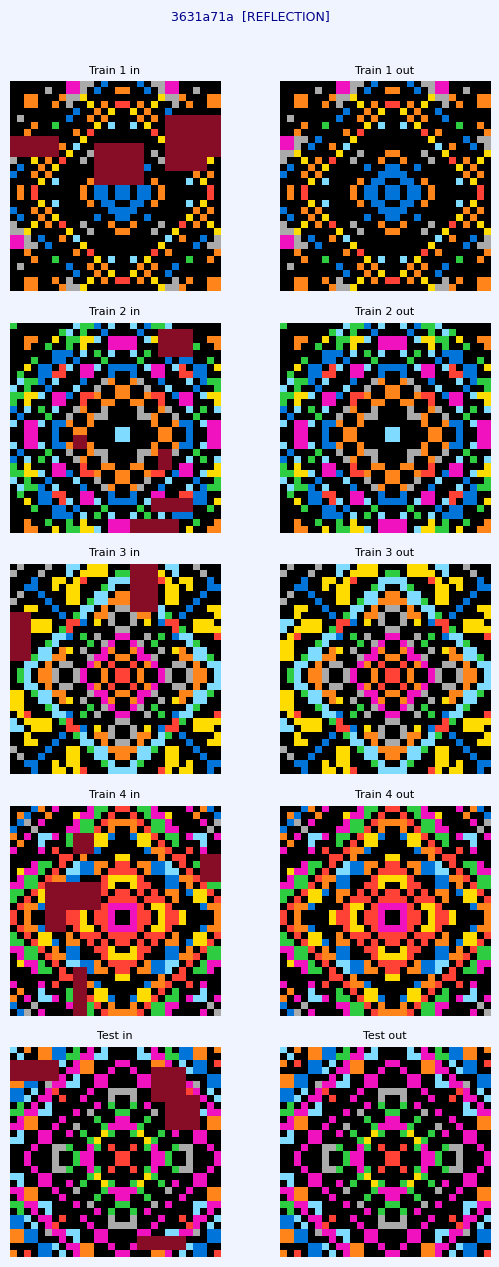

  TYPE: symmetry restoration (reflection)
  SCENE: Large 30x30 grid, bilaterally symmetric pattern with a rectangular hole filled with 9s.
  MECHANISM: Identify symmetry axis of non-9 region; for each masked cell copy its symmetric counterpart.


  9ecd008a  (3 train pairs)  [REFLECTION]


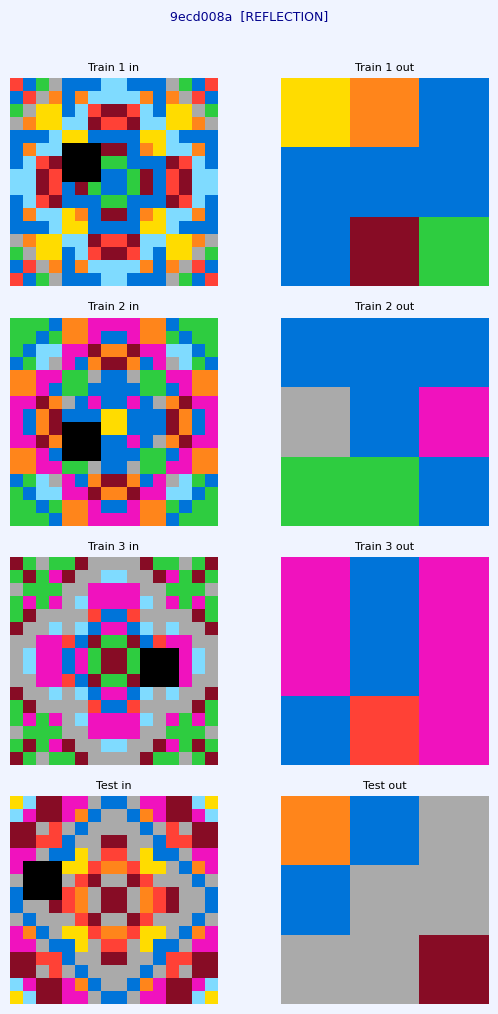

  TYPE: symmetry-based hole reconstruction
  SCENE: 16x16 complex symmetric grid with a single 3x3 block of zeros acting as a hole.
  MECHANISM: Recover the 3 cells that belong in the hole by referencing the grid's inherent symmetry. Output is exactly 3x3.


  b8825c91  (4 train pairs)  [REFLECTION]


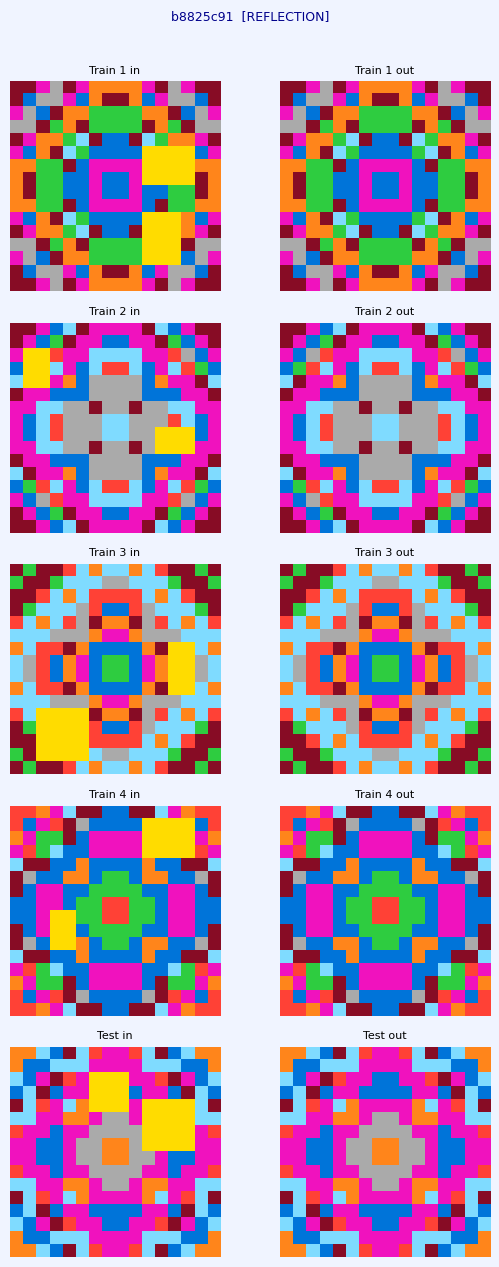

  TYPE: symmetry restoration (reflection)
  SCENE: 16x16 grid with symmetric coloured pattern and a rectangular hole of 9s.
  MECHANISM: Detect symmetry axis, fill masked region by reading symmetric counterpart cells.


  0dfd9992  (3 train pairs)  [TRANSLATION]


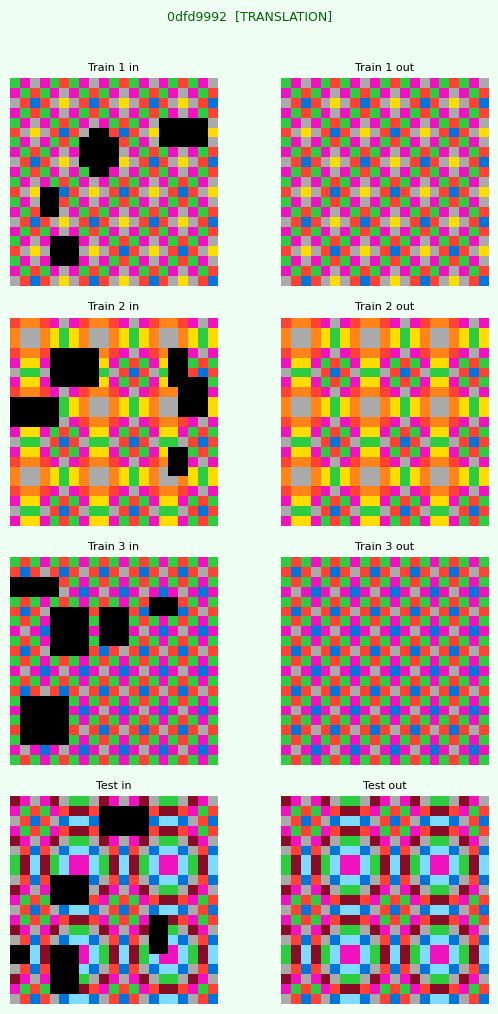

  TYPE: periodic pattern restoration (translation)
  SCENE: Perfectly periodic tiling pattern with scattered rectangular holes of 0s punched through it.
  MECHANISM: Detect repeating period, fill each zero with the colour that belongs at that position in the complete tiling.


  29ec7d0e  (4 train pairs)  [TRANSLATION]


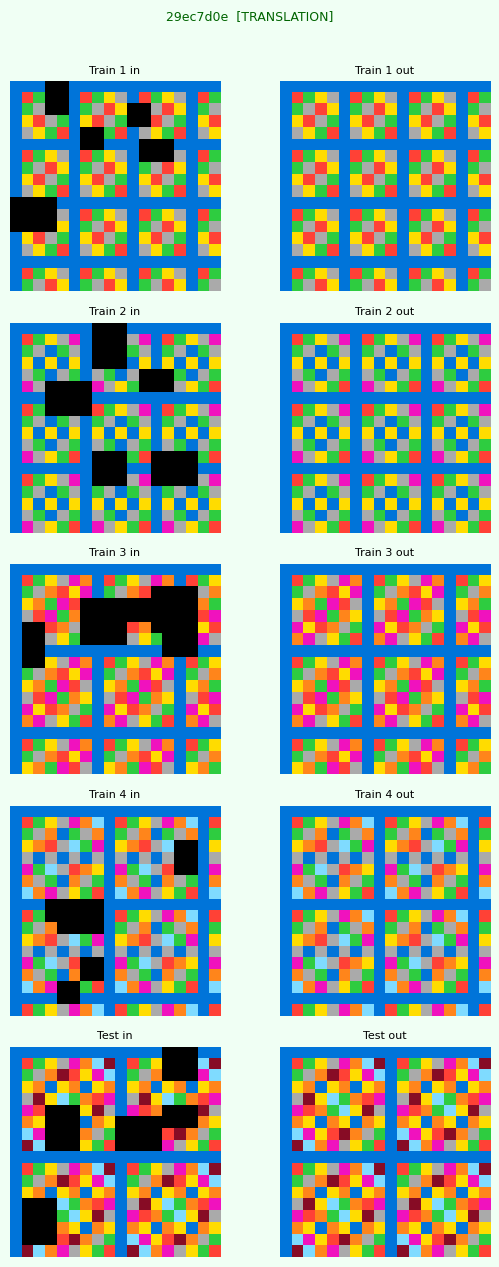

  TYPE: periodic pattern restoration (translation)
  SCENE: Repeating row-colour sequence (colours 1-7) interrupted by scattered zero cells.
  MECHANISM: Identify period, replace all zeros with correct values from the periodic tiling rule.


  484b58aa  (3 train pairs)  [TRANSLATION]


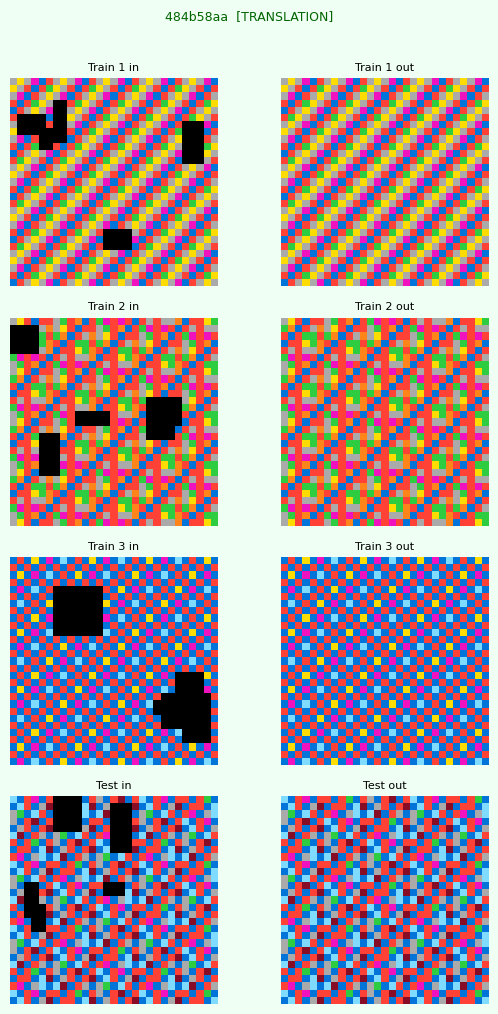

  TYPE: periodic pattern restoration (translation)
  SCENE: Periodic tessellation with rectangular zero-filled holes at various positions.
  MECHANISM: Extend the tiling consistently, replacing zeros with values from the inferred period.


  73251a56  (3 train pairs)  [TRANSLATION]


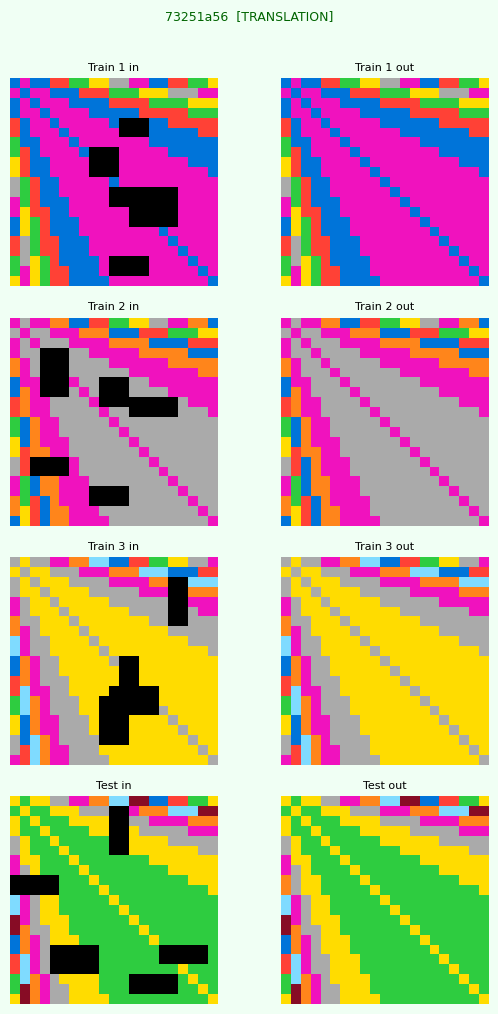

  TYPE: diagonal pattern restoration (translation)
  SCENE: 21x21 grid with diagonal colour stripes overlaid with rectangular blocks of zeros.
  MECHANISM: Restore each zero region with the colour that the diagonal stripe pattern dictates at that position.


  c3f564a4  (3 train pairs)  [TRANSLATION]


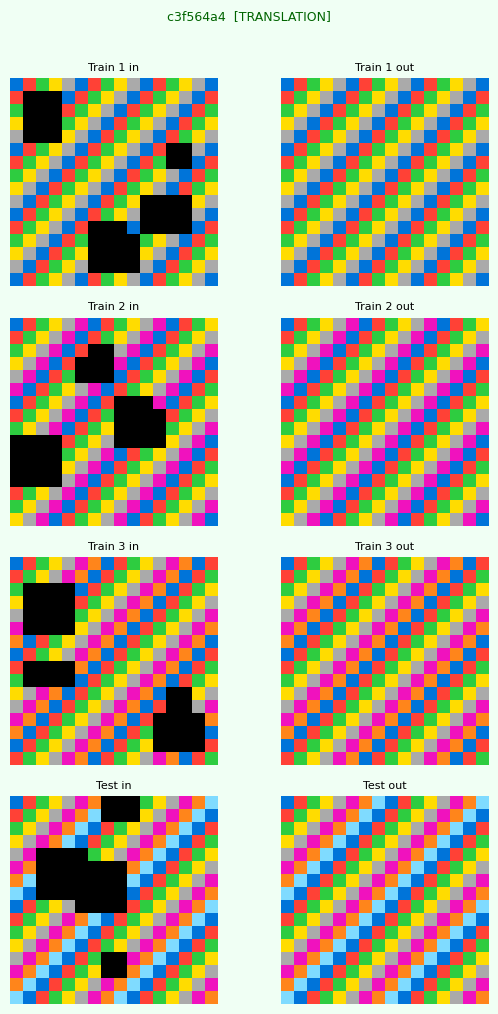

  TYPE: cyclic pattern restoration (translation)
  SCENE: 16x16 grid with repeating cyclic colour sequence (5-7 colours) broken by scattered zero regions.
  MECHANISM: Identify cycle length, fill zeros with colour at (row, col) mod cycle_length.


  3345333e  (2 train pairs)  [UNCERTAIN]


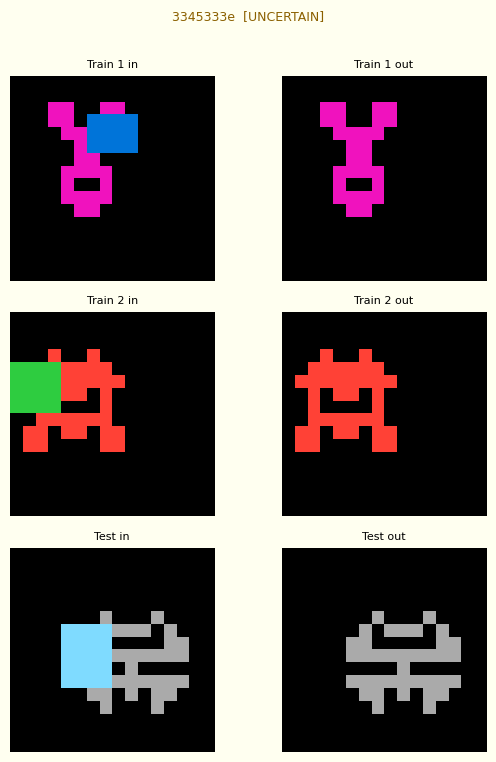

  TYPE: overlay removal (uncertain fit)
  SCENE: Primary coloured pattern plus a separate solid rectangular block of a different colour overlaid on it.
  MECHANISM: Delete all cells of the secondary colour — the primary pattern is already complete beneath it.
  NOTE: May be different from restoration tasks — the underlying pattern doesn't need to be inferred, just uncovered.



In [3]:
for tid in task_ids:
    desc = TASKS[tid]
    is_reflection  = tid in REFLECTION_IDS
    is_translation = tid in TRANSLATION_IDS
    is_uncertain   = tid in UNCERTAIN_IDS

    task_path = DATA_DIR / f'{tid}.json'
    if not task_path.exists():
        print(f'!! {tid}: file not found at {task_path}')
        continue
    task  = json.loads(task_path.read_text())
    pairs = task['train']
    n_rows = len(pairs) + 1

    if is_reflection:
        group, bg, fg = 'REFLECTION', '#f0f4ff', '#00008B'
    elif is_translation:
        group, bg, fg = 'TRANSLATION', '#f0fff4', '#006400'
    else:
        group, bg, fg = 'UNCERTAIN',   '#fffff0', '#8B6000'

    print(f"\n{'='*60}")
    print(f'  {tid}  ({len(pairs)} train pairs)  [{group}]')
    print(f"{'='*60}")

    fig, axes = plt.subplots(n_rows, 2, figsize=(6, 2.5 * n_rows), squeeze=False)
    fig.patch.set_facecolor(bg)
    fig.suptitle(f'{tid}  [{group}]', fontsize=9, color=fg, y=1.01)

    for i, pair in enumerate(pairs):
        show_grid(axes[i, 0], pair['input'],  f'Train {i+1} in')
        show_grid(axes[i, 1], pair['output'], f'Train {i+1} out')

    test = task['test'][0]
    show_grid(axes[-1, 0], test['input'], 'Test in')
    if 'output' in test:
        show_grid(axes[-1, 1], test['output'], 'Test out')
    else:
        axes[-1, 1].axis('off')
        axes[-1, 1].set_title('Test out (hidden)', fontsize=8)

    plt.tight_layout()
    plt.show()

    for line in desc.split('\n'):
        print(f'  {line}')
    print()